In [51]:
#%% Import
from LiCSBAS_meta import *
import getopt
import os
import sys
import time
import shutil
from osgeo import gdal
import glob
import numpy as np
import subprocess as subp
import multiprocessing as multi
import cmcrameri.cm as cmc #SCM
# import LiCSBAS_io_lib as io_lib
import LiCSBAS_tools_lib as tools_lib
# import LiCSBAS_plot_lib as plot_lib
import matplotlib.pyplot as plt

In [2]:
geocdir="/work/scratch-pw4/licsar/mnergiz/TR_interseismic/021D_05266_252525/GEOC"

In [3]:
tif = glob.glob(os.path.join(geocdir, '*.tif'))[0]
geotiff = gdal.Open(tif)
width = geotiff.RasterXSize
length = geotiff.RasterYSize
geotiff = None


In [8]:
ifgd="20190114_20190120"
suffix = ['.geo.sbovldiff.adf.mm.tif', '.geo.cc.tif', '.sbovldiff.adf.mm', '.cc']
cycle = 75

# Check for sbovldiff files first
unw_tiffile = os.path.join(geocdir, ifgd, ifgd + suffix[0])
cc_tiffile = os.path.join(geocdir, ifgd, ifgd + suffix[1])
if not os.path.exists(unw_tiffile) or not os.path.exists(cc_tiffile):
    print(f'  No {ifgd + suffix[0]} or {ifgd + suffix[1]} found. Checking bovldiff files...', flush=True)

    # Fall back to bovldiff if sbovldiff not found
    unw_tiffile = os.path.join(geocdir, ifgd, ifgd + '.geo.bovldiff.adf.mm.tif')
    cc_tiffile = os.path.join(geocdir, ifgd, ifgd + '.geo.cc.tif')

    if not os.path.exists(unw_tiffile) or not os.path.exists(cc_tiffile):
        print(f'  No {ifgd + ".geo.bovldiff.adf.mm.tif"} or {ifgd + ".geo.cc.tif"} found. Skip.', flush=True)


In [61]:
import lics_unwrap
outdir="/work/scratch-pw4/licsar/mnergiz/TR_interseismic"
# Output directories and files
ifgdir1 = os.path.join(outdir, ifgd)
if not os.path.exists(ifgdir1):
    os.mkdir(ifgdir1)
unwfile = os.path.join(ifgdir1, ifgd + suffix[2])
ccfile = os.path.join(ifgdir1, ifgd + suffix[3])
unw_xr=lics_unwrap.load_tif2xr(unw_tiffile)
cc_xr=lics_unwrap.load_tif2xr(cc_tiffile)


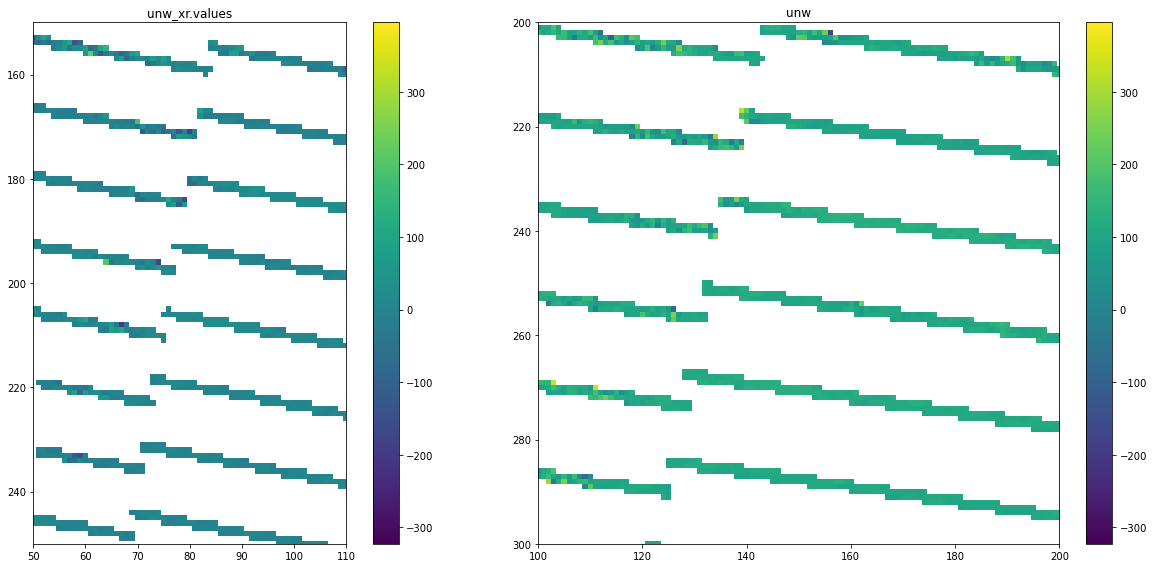

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left
im0 = axes[0].imshow(da_15.values)
axes[0].set_title("unw_xr.values")
axes[0].set_xlim(50, 110)
axes[0].set_ylim(250, 150)   # inverted y-axis (image coordinates)
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Right
im1 = axes[1].imshow(unw)
axes[1].set_title("unw")
axes[1].set_xlim(100, 200)
axes[1].set_ylim(300, 200)
plt.colorbar(im0, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


Approx pixel size (m): dx= 88.5519117375 dy= 111.31999999974056
Block size (pixels):   fx= 17 fy= 13
Output shape: (361, 227)


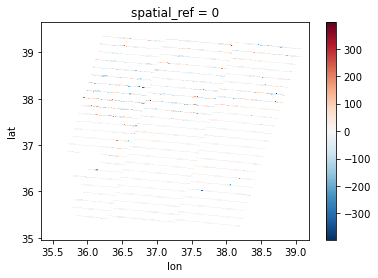

In [134]:
import numpy as np
import xarray as xr

def coarsen_nanmedian_km(
    da: xr.DataArray,
    x_km: float,
    y_km: float,
    min_valid_frac: float = 0.10,
    boundary: str = "trim",
):
    """
    Downsample (lat, lon) DataArray to ~y_km (lat direction) and ~x_km (lon direction)
    using NaN-safe median, and mask blocks with too few valid pixels.

    Returns
    -------
    da_out : xr.DataArray
    info : dict  (dx/dy meters per pixel + fx/fy pixels)
    """
    if "lat" not in da.dims or "lon" not in da.dims:
        raise ValueError(f"Expected dims ('lat','lon'); got {da.dims}")

    # degrees per pixel (assumes regular grid)
    dlat = float(np.abs(da.lat.values[1] - da.lat.values[0]))
    dlon = float(np.abs(da.lon.values[1] - da.lon.values[0]))

    # meters per degree (approx, at mid-lat)
    lat0 = float(da.lat.mean())
    m_per_deg_lat = 111_320.0
    m_per_deg_lon = 111_320.0 * np.cos(np.deg2rad(lat0))

    # meters per pixel
    dy_m = dlat * m_per_deg_lat
    dx_m = dlon * m_per_deg_lon

    # target meters
    target_x_m = x_km * 1000.0
    target_y_m = y_km * 1000.0

    # block size in pixels
    fy = max(1, int(round(target_y_m / dy_m)))  # along lat (rows)
    fx = max(1, int(round(target_x_m / dx_m)))  # along lon (cols)

    # NaN-safe median
    da_out = da.coarsen(lat=fy, lon=fx, boundary=boundary).median(skipna=True)

    # mask blocks with too few valid pixels
    if min_valid_frac is not None:
        frac_valid = np.isfinite(da).coarsen(lat=fy, lon=fx, boundary=boundary).mean()
        da_out = da_out.where(frac_valid >= float(min_valid_frac))

    info = dict(
        dx_m_per_pix=dx_m,
        dy_m_per_pix=dy_m,
        fx_pix=fx,
        fy_pix=fy,
        x_km=x_km,
        y_km=y_km,
        min_valid_frac=min_valid_frac,
        boundary=boundary,
    )
    return da_out, info


# -------------------------
# Your requested test:
# Y = 15 km, X = 20 km
# -------------------------
da_20x15, info = coarsen_nanmedian_km(
    unw_xr,
    x_km=1.5,     # lon direction
    y_km=1.5,     # lat direction
    min_valid_frac=0.10,   # try 0.01 if data are very sparse
    boundary="trim",
)

print("Approx pixel size (m): dx=", info["dx_m_per_pix"], "dy=", info["dy_m_per_pix"])
print("Block size (pixels):   fx=", info["fx_pix"], "fy=", info["fy_pix"])
print("Output shape:", da_20x15.shape)
da_20x15.plot()

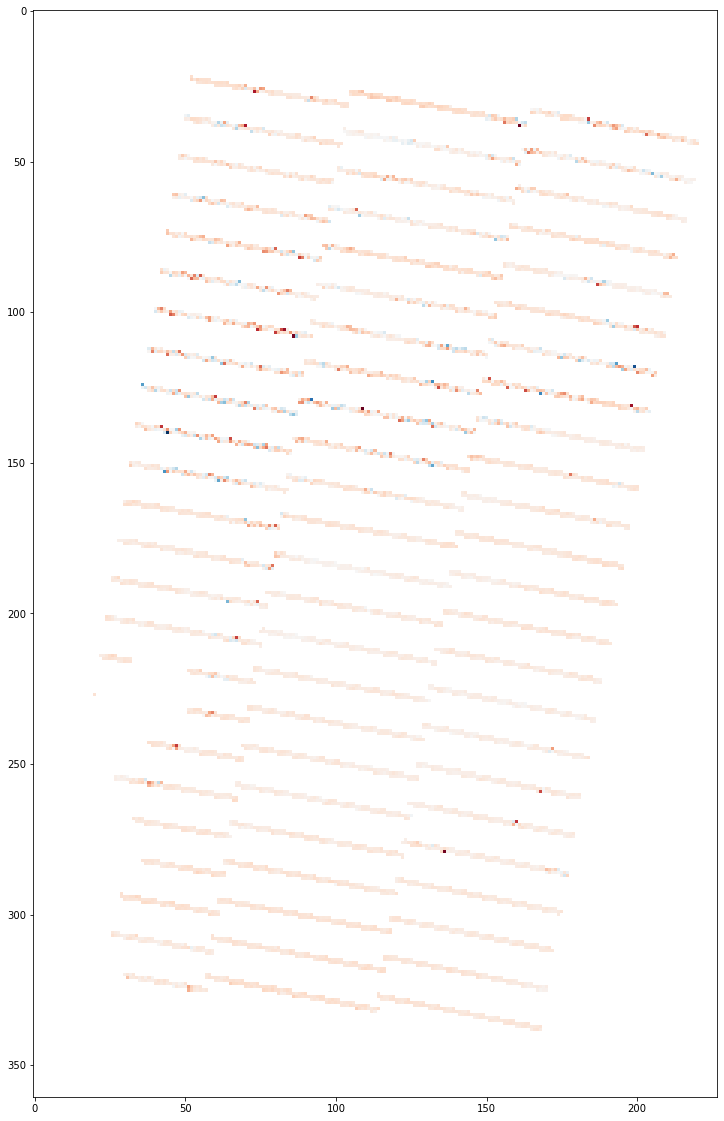

In [135]:
plt.figure(figsize=(20,20))
plt.imshow(da_20x15.values, cmap="RdBu")

In [68]:
import numpy as np

da = unw_xr  # xarray.DataArray with dims ('lat','lon')

# degrees per pixel
dlat = float(np.abs(da.lat[1] - da.lat[0]))
dlon = float(np.abs(da.lon[1] - da.lon[0]))

# meters per degree
lat0 = float(da.lat.mean())
m_per_deg_lat = 111_320.0
m_per_deg_lon = 111_320.0 * np.cos(np.deg2rad(lat0))

# meters per pixel
dy = dlat * m_per_deg_lat
dx = dlon * m_per_deg_lon

dy, dx


(111.31999999974056, 88.551911737481305)

In [96]:
import numpy as np

da = unw_xr  # xarray.DataArray with dims ('lat','lon')

# degrees per pixel
dlat = float(np.abs(da.lat[1] - da.lat[0]))
dlon = float(np.abs(da.lon[1] - da.lon[0]))

# meters per degree
lat0 = float(da.lat.mean())
m_per_deg_lat = 111_320.0
m_per_deg_lon = 111_320.0 * np.cos(np.deg2rad(lat0))

# meters per pixel
dy = dlat * m_per_deg_lat
dx = dlon * m_per_deg_lon

dy, dx


target_m = 1500.0
fy = max(1, int(round(target_m / dy)))  # along 'lat' axis (rows)
fx = max(1, int(round(target_m / dx)))  # along 'lon' axis (cols)

fy, fx

da_15 = da.coarsen(lat=fy, lon=fx, boundary="trim").median(skipna=True)
da_15

valid = np.isfinite(da)
frac_valid = valid.coarsen(lat=fy, lon=fx, boundary="trim").mean()

da_15 = da_15.where(frac_valid >= 0.10)


In [97]:
da_15

<xarray.DataArray (lat: 361, lon: 227)>
array([[ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       ..., 
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan]], dtype=float32)
Coordinates:
  * lon          (lon) float64 35.34 35.36 35.37 35.39 ... 39.15 39.16 39.18
  * lat          (lat) float64 39.64 39.63 39.61 39.6 ... 35.0 34.99 34.97 34.96
    spatial_ref  int64 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

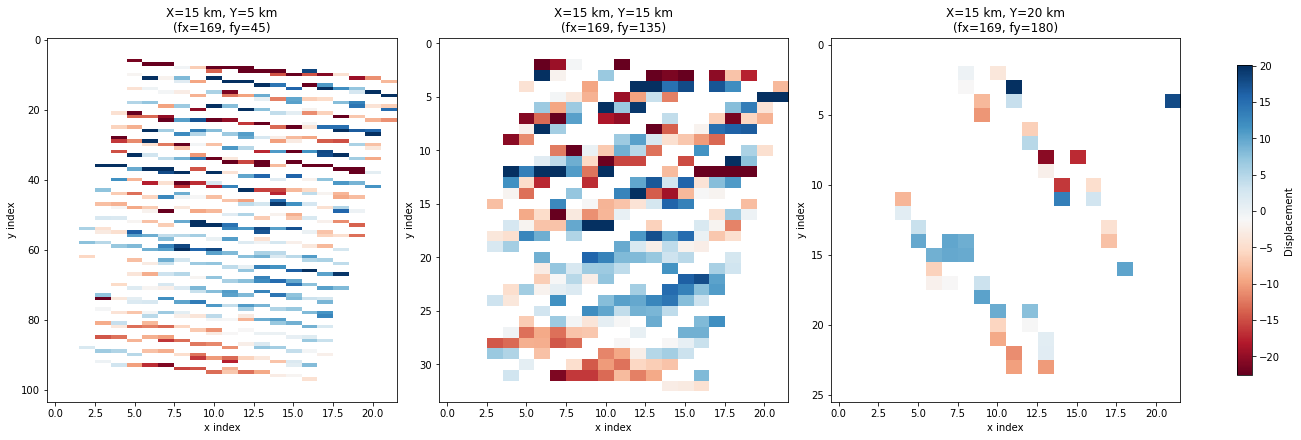

In [95]:
import matplotlib.pyplot as plt
import numpy as np

# --- choose which results to plot ---
plot_keys = [
    (15.0, 5.0),
    (15.0, 15.0),
    (15.0, 20.0),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

# --- compute shared color scale from full arrays ---
vals_flat = []
for k in plot_keys:
    da, _ = results[k]
    vals_flat.append(da.values.ravel())

all_vals = np.concatenate(vals_flat)
all_vals = all_vals[np.isfinite(all_vals)]

vmin = np.percentile(all_vals, 5)
vmax = np.percentile(all_vals, 95)

# --- plot ---
for ax, key in zip(axes, plot_keys):
    da, info = results[key]

    im = ax.imshow(
        da.values,
        cmap="RdBu",
        vmin=vmin,
        vmax=vmax,
        aspect="auto"
    )

    ax.set_title(
        f"X={info['target_x_m']/1000:.0f} km, "
        f"Y={info['target_y_m']/1000:.0f} km\n"
        f"(fx={info['fx_pix']}, fy={info['fy_pix']})"
    )

    ax.set_xlabel("x index")
    ax.set_ylabel("y index")

# --- shared colorbar ---
cbar = fig.colorbar(im, ax=axes, shrink=0.85)
cbar.set_label("Displacement")

plt.show()


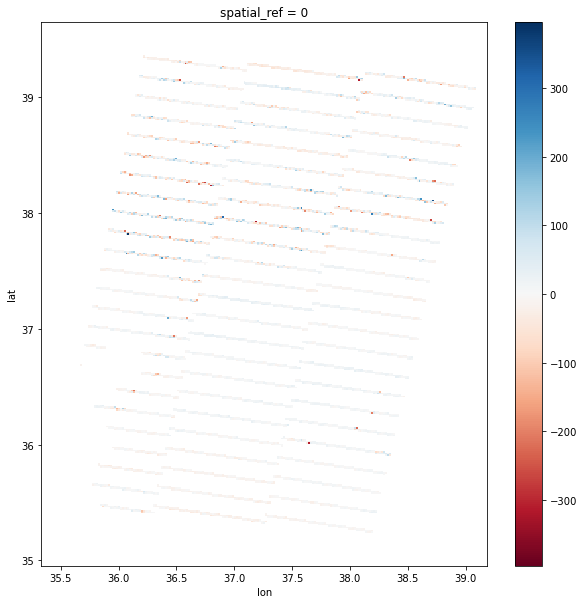

In [87]:
plt.figure(figsize=(10,10))
da_15.plot(cmap="RdBu")